# Prática 01 — Caminho Mínimo

**Disciplina:** Teoria de Grafos  
**Objetivo:** Implementar e testar algoritmo de Dijkstra e heurística gulosa.

**Estrutura:**
- Letras (a)-(e): Preparação e teste em grafos completos pequenos
- Letra (f): Aplicação nas instâncias grandes (10k e 1M vértices)

---

In [6]:
# Imports necessários
from typing import Dict, List, Tuple
from collections import deque
from math import inf
import heapq, random, os
import matplotlib.pyplot as plt
import numpy as np

---
# PARTE 1: ALGORITMO DE DIJKSTRA
---

## I. Implementação do Algoritmo de Dijkstra

In [7]:
def dijkstra(adj: Dict[int, List[Tuple[int, float]]], origem: int = 0):
    """
    Algoritmo de Dijkstra para caminho mínimo de origem única.
    
    Retorna: (dist, parent, comparacoes)
    """
    if not adj or origem not in adj:
        raise ValueError('Grafo vazio ou origem inválida')
    
    # Inicialização
    dist = {u: inf for u in adj}
    parent = {u: None for u in adj}
    dist[origem] = 0.0
    pq = [(0.0, origem)]
    comparacoes = 0
    
    # Loop principal
    while pq:
        dist_u, u = heapq.heappop(pq)
        if dist_u != dist[u]:
            continue
        
        for v, peso in adj[u]:
            comparacoes += 1
            nova_dist = dist[u] + peso
            if nova_dist < dist[v]:
                dist[v] = nova_dist
                parent[v] = u
                heapq.heappush(pq, (nova_dist, v))
    
    return dist, parent, comparacoes

## II. Teste do Algoritmo

### Configurações

In [8]:
# Parâmetros
N_MIN = 4
N_MAX = 1000     # Grafos completos pequenos para teste
SEED = 42
ORIGEM = 0
# Escolher o grafo n=5 (índice 1, já que ns_teste começa em 4)
n_exemplo = 10

### (a) Gerar grafos completos com pesos > 0

In [9]:
def gerar_grafo_completo(n: int, peso_min: float = 1.0, peso_max: float = 10.0, seed: int = None):
    """Gera grafo completo dirigido com n vértices."""
    if seed is not None:
        random.seed(seed)
    
    adj = {u: [] for u in range(n)}
    for u in range(n):
        for v in range(n):
            if u != v:
                peso = random.uniform(peso_min, peso_max)
                adj[u].append((v, peso))
    return adj

print(f"✓ Função de geração de grafos completos criada")
print(f"  Teste: grafo com 5 vértices tem {5*(5-1)} arestas esperadas")

✓ Função de geração de grafos completos criada
  Teste: grafo com 5 vértices tem 20 arestas esperadas


### (b) Armazenar grafos em estrutura de dados

**Estrutura:** Lista de adjacência `{vértice: [(vizinho, peso), ...]}`

In [10]:
# Gerar grafos completos de teste (n=4 até n=10)
ns_teste = list(range(N_MIN, N_MAX + 1))
grafos_teste = [gerar_grafo_completo(n, seed=SEED) for n in ns_teste]

print(f"✓ Gerados {len(grafos_teste)} grafos completos de teste")
print(f"  Tamanhos: n={N_MIN} até n={N_MAX}")

✓ Gerados 997 grafos completos de teste
  Tamanhos: n=4 até n=1000


### Exemplo de visualização de um grafo

✓ Grafo de exemplo (n=10) plotado e salvo
  Arquivo: resultados/dijkstra/img/grafo_exemplo_n10.png


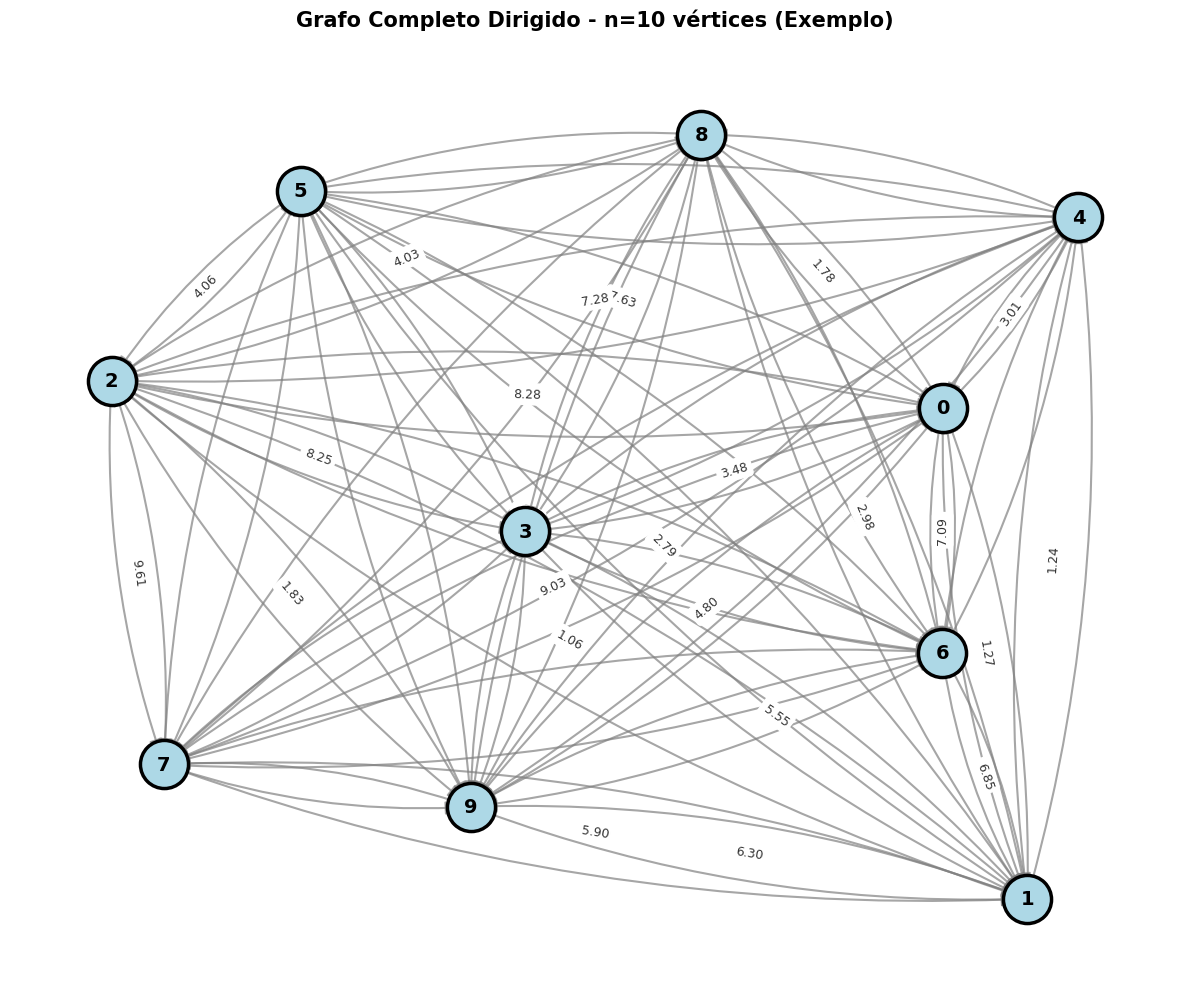

In [11]:
# Plotar apenas um grafo de exemplo (n=5) usando NetworkX
import networkx as nx


idx_exemplo = ns_teste.index(n_exemplo) if n_exemplo in ns_teste else 1
grafo_exemplo = grafos_teste[idx_exemplo]

# Criar grafo direcionado NetworkX
G = nx.DiGraph()
for u, vizinhos in grafo_exemplo.items():
    for v, peso in vizinhos:
        G.add_edge(u, v, weight=peso)

# Plotar
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=SEED, k=1.5, iterations=50)

# Desenhar nós
nx.draw_networkx_nodes(G, pos, node_color='lightblue', 
                      node_size=1200, edgecolors='black', linewidths=2.5)

# Desenhar arestas
nx.draw_networkx_edges(G, pos, edge_color='gray', 
                      arrows=True, arrowsize=20, width=1.5,
                      connectionstyle='arc3,rad=0.1', alpha=0.7)

# Labels dos nós
nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold')

# Labels das arestas (pesos) - apenas alguns para não poluir
edge_labels = nx.get_edge_attributes(G, 'weight')
# Mostrar apenas arestas de vértices 0, 1, 2 para clareza
edge_labels_filtrado = {k: f'{v:.2f}' for k, v in edge_labels.items() if k[0] < 3}
nx.draw_networkx_edge_labels(G, pos, edge_labels_filtrado, font_size=9, alpha=0.8)

plt.title(f'Grafo Completo Dirigido - n={n_exemplo} vértices (Exemplo)', 
         fontsize=15, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()

# Salvar
os.makedirs('resultados/dijkstra/img', exist_ok=True)
plt.savefig(f'resultados/dijkstra/img/grafo_exemplo_n{n_exemplo}.png', dpi=200, bbox_inches='tight')
print(f'✓ Grafo de exemplo (n={n_exemplo}) plotado e salvo')
print(f'  Arquivo: resultados/dijkstra/img/grafo_exemplo_n{n_exemplo}.png')
plt.show()

### (c) Aplicar algoritmo de Dijkstra

In [12]:
# Aplicar Dijkstra nos grafos de teste
resultados_teste = [dijkstra(g, origem=ORIGEM) for g in grafos_teste]

print(f"✓ Dijkstra executado em {len(resultados_teste)} grafos de teste")
print(f"\nExemplos de comparações:")
for i in range(min(3, len(ns_teste))):
    comp = resultados_teste[i][2]
    print(f"  n={ns_teste[i]}: {comp} comparações")

✓ Dijkstra executado em 997 grafos de teste

Exemplos de comparações:
  n=4: 12 comparações
  n=5: 20 comparações
  n=6: 30 comparações


### (d) Contar número de comparações

In [13]:
# Extrair comparações
comparacoes_teste = [r[2] for r in resultados_teste]

# Salvar resultados de teste
os.makedirs('resultados/dijkstra', exist_ok=True)
with open('resultados/dijkstra/teste_comparacoes.txt', 'w') as f:
    f.write('n\tcomparacoes\n')
    for n, comp in zip(ns_teste, comparacoes_teste):
        f.write(f'{n}\t{comp}\n')

print('✓ Comparações contadas e salvas')
print(f'  Arquivo: resultados/dijkstra/teste_comparacoes.txt')

✓ Comparações contadas e salvas
  Arquivo: resultados/dijkstra/teste_comparacoes.txt


### (e) Plotar gráfico: n vs comparações

✓ Gráfico de teste salvo: resultados/dijkstra/img/teste_comparacoes.png


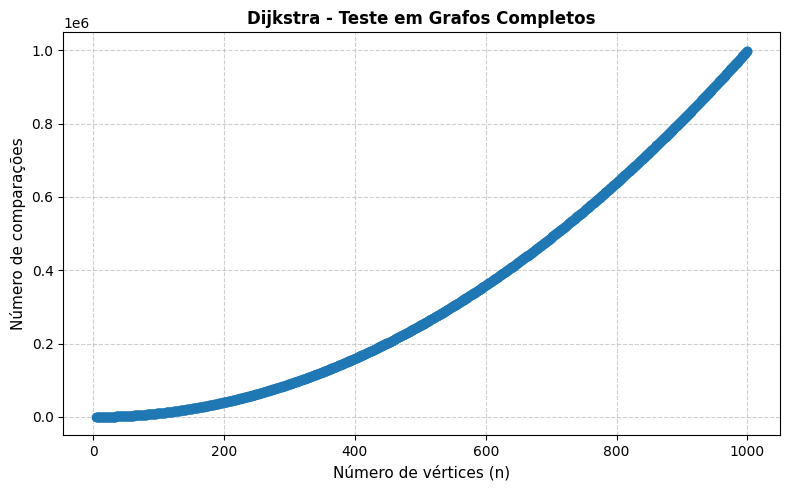

In [14]:
# Gráfico de teste
plt.figure(figsize=(8, 5))
plt.plot(ns_teste, comparacoes_teste, marker='o', linewidth=2, markersize=6)
plt.xlabel('Número de vértices (n)', fontsize=11)
plt.ylabel('Número de comparações', fontsize=11)
plt.title('Dijkstra - Teste em Grafos Completos', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

os.makedirs('resultados/dijkstra/img', exist_ok=True)
plt.savefig('resultados/dijkstra/img/teste_comparacoes.png', dpi=150)
print('✓ Gráfico de teste salvo: resultados/dijkstra/img/teste_comparacoes.png')
plt.show()

### (f) Aplicar em instâncias grandes (10k e 1M vértices)

**Agora aplicamos o algoritmo testado nas instâncias grandes.**

In [15]:
def carregar_grafo_ewd(caminho: str):
    """Carrega grafo em formato EWD."""
    with open(caminho, 'r', encoding='utf-8') as f:
        V = int(f.readline().strip())
        E = int(f.readline().strip())
        adj = {i: [] for i in range(V)}
        
        for _ in range(E):
            linha = f.readline().strip()
            if not linha:
                break
            u, v, peso = linha.split()[:3]
            adj[int(u)].append((int(v), float(peso)))
    return adj

print('✓ Função de carregamento de grafos grandes criada')

✓ Função de carregamento de grafos grandes criada


In [16]:
# Caminhos das instâncias
caminho_10k = r'D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\10000.txt'
caminho_1m = r'D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\largeEWD - contains one million vertices and 15172126 edges.txt'

print('Caminhos configurados:')
print(f'  10k:  {os.path.exists(caminho_10k) and "✓ Encontrado" or "✗ Não encontrado"}')
print(f'  1M:   {os.path.exists(caminho_1m) and "✓ Encontrado" or "✗ Não encontrado"}')

Caminhos configurados:
  10k:  ✓ Encontrado
  1M:   ✓ Encontrado


In [17]:
# Executar Dijkstra na instância 10k
print('='*70)
print('EXECUTANDO DIJKSTRA - INSTÂNCIA 10.000 VÉRTICES')
print('='*70)

if os.path.exists(caminho_10k):
    print('Carregando grafo...')
    grafo_10k = carregar_grafo_ewd(caminho_10k)
    print(f'✓ Carregado: {len(grafo_10k):,} vértices')
    
    print(f'Executando Dijkstra (origem={ORIGEM})...')
    dist_10k, parent_10k, comp_dijkstra_10k = dijkstra(grafo_10k, origem=ORIGEM)
    
    alcancados_10k = sum(1 for d in dist_10k.values() if d != inf)
    
    print(f'\n📊 RESULTADOS:')
    print(f'   Vértices: {len(dist_10k):,}')
    print(f'   Comparações: {comp_dijkstra_10k:,}')
    print(f'   Alcançados: {alcancados_10k:,}')
    
    # Salvar
    os.makedirs('resultados/dijkstra/instancias', exist_ok=True)
    with open('resultados/dijkstra/instancias/10k_dijkstra.txt', 'w') as f:
        f.write('DIJKSTRA - Instância 10.000 vértices\n')
        f.write('='*60 + '\n')
        f.write(f'Origem: {ORIGEM}\n')
        f.write(f'Vértices: {len(dist_10k):,}\n')
        f.write(f'Comparações: {comp_dijkstra_10k:,}\n')
        f.write(f'Alcançados: {alcancados_10k:,}\n')
    print('💾 Salvo: resultados/dijkstra/instancias/10k_dijkstra.txt')
else:
    print('⚠️ Arquivo não encontrado!')
    comp_dijkstra_10k = None

EXECUTANDO DIJKSTRA - INSTÂNCIA 10.000 VÉRTICES
Carregando grafo...
✓ Carregado: 10,000 vértices
Executando Dijkstra (origem=0)...

📊 RESULTADOS:
   Vértices: 10,000
   Comparações: 123,462
   Alcançados: 10,000
💾 Salvo: resultados/dijkstra/instancias/10k_dijkstra.txt


In [18]:
# Executar Dijkstra na instância 1M (DESCOMENTE PARA EXECUTAR)

print('='*70)
print('EXECUTANDO DIJKSTRA - INSTÂNCIA 1.000.000 VÉRTICES')
print('='*70)

if os.path.exists(caminho_1m):
    print('Carregando grafo...')
    grafo_1m = carregar_grafo_ewd(caminho_1m)
    print(f'✓ Carregado: {len(grafo_1m):,} vértices')
    
    print(f'Executando Dijkstra (origem={ORIGEM})...')
    dist_1m, parent_1m, comp_dijkstra_1m = dijkstra(grafo_1m, origem=ORIGEM)
    
    alcancados_1m = sum(1 for d in dist_1m.values() if d != inf)
    
    print(f'\n📊 RESULTADOS:')
    print(f'   Vértices: {len(dist_1m):,}')
    print(f'   Comparações: {comp_dijkstra_1m:,}')
    print(f'   Alcançados: {alcancados_1m:,}')
    
    # Salvar
    with open('resultados/dijkstra/instancias/1m_dijkstra.txt', 'w') as f:
        f.write('DIJKSTRA - Instância 1.000.000 vértices\n')
        f.write('='*60 + '\n')
        f.write(f'Origem: {ORIGEM}\n')
        f.write(f'Vértices: {len(dist_1m):,}\n')
        f.write(f'Comparações: {comp_dijkstra_1m:,}\n')
        f.write(f'Alcançados: {alcancados_1m:,}\n')
    print('💾 Salvo: resultados/dijkstra/instancias/1m_dijkstra.txt')
else:
    print('⚠️ Arquivo não encontrado!')
    comp_dijkstra_1m = None

print('ℹ️  Instância 1M comentada. Descomente o bloco acima para executar.')

EXECUTANDO DIJKSTRA - INSTÂNCIA 1.000.000 VÉRTICES
Carregando grafo...
✓ Carregado: 1,000,000 vértices
Executando Dijkstra (origem=0)...

📊 RESULTADOS:
   Vértices: 1,000,000
   Comparações: 15,172,126
   Alcançados: 1,000,000
💾 Salvo: resultados/dijkstra/instancias/1m_dijkstra.txt
ℹ️  Instância 1M comentada. Descomente o bloco acima para executar.


---
# PARTE 2: HEURÍSTICA GULOSA
---

## I. Implementação da Heurística Gulosa

In [19]:
def heuristica_gulosa(adj: Dict[int, List[Tuple[int, float]]], origem: int = 0):
    """
    Heurística gulosa (vizinho mais próximo).
    ATENÇÃO: NÃO garante solução ótima!
    
    Retorna: (dist, parent, comparacoes)
    """
    if origem not in adj:
        raise ValueError('Origem inválida')
    
    dist = {u: inf for u in adj}
    parent = {u: None for u in adj}
    dist[origem] = 0.0
    visited = {origem}
    fila = deque([origem])
    comparacoes = 0
    
    while fila:
        u = fila.popleft()
        melhor_v = None
        melhor_custo = inf
        
        for v, peso in adj[u]:
            comparacoes += 1
            if v in visited:
                continue
            custo = dist[u] + peso
            if custo < dist[v] and custo < melhor_custo:
                melhor_custo = custo
                melhor_v = v
        
        if melhor_v is not None:
            dist[melhor_v] = melhor_custo
            parent[melhor_v] = u
            visited.add(melhor_v)
            fila.append(melhor_v)
    
    return dist, parent, comparacoes

## II. Teste da Heurística

### (a) e (b) Reutilizar grafos completos de teste

Usamos os mesmos grafos gerados para testar Dijkstra.

In [20]:
print(f"✓ Reutilizando {len(grafos_teste)} grafos de teste")
print(f"  Tamanhos: n={N_MIN} até n={N_MAX}")

✓ Reutilizando 997 grafos de teste
  Tamanhos: n=4 até n=1000


### (c) Aplicar heurística gulosa

In [21]:
# Aplicar heurística gulosa nos grafos de teste
resultados_gulosa_teste = [heuristica_gulosa(g, origem=ORIGEM) for g in grafos_teste]

print(f"✓ Heurística gulosa executada em {len(resultados_gulosa_teste)} grafos")
print(f"\nExemplos de comparações:")
for i in range(min(3, len(ns_teste))):
    comp = resultados_gulosa_teste[i][2]
    print(f"  n={ns_teste[i]}: {comp} comparações")

✓ Heurística gulosa executada em 997 grafos

Exemplos de comparações:
  n=4: 12 comparações
  n=5: 20 comparações
  n=6: 30 comparações


### (d) Contar número de comparações

In [22]:
# Extrair comparações
comparacoes_gulosa_teste = [r[2] for r in resultados_gulosa_teste]

# Salvar
os.makedirs('resultados/gulosa', exist_ok=True)
with open('resultados/gulosa/teste_comparacoes.txt', 'w') as f:
    f.write('n\tcomparacoes\n')
    for n, comp in zip(ns_teste, comparacoes_gulosa_teste):
        f.write(f'{n}\t{comp}\n')

print('✓ Comparações contadas e salvas')
print(f'  Arquivo: resultados/gulosa/teste_comparacoes.txt')

✓ Comparações contadas e salvas
  Arquivo: resultados/gulosa/teste_comparacoes.txt


### (e) Plotar gráfico: n vs comparações

✓ Gráfico de teste salvo: resultados/gulosa/img/teste_comparacoes.png


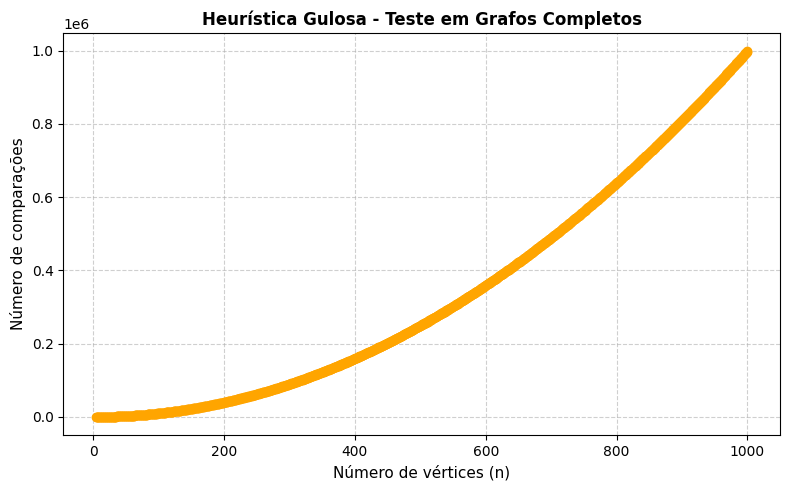

In [23]:
# Gráfico de teste
plt.figure(figsize=(8, 5))
plt.plot(ns_teste, comparacoes_gulosa_teste, marker='o', color='orange', linewidth=2, markersize=6)
plt.xlabel('Número de vértices (n)', fontsize=11)
plt.ylabel('Número de comparações', fontsize=11)
plt.title('Heurística Gulosa - Teste em Grafos Completos', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

os.makedirs('resultados/gulosa/img', exist_ok=True)
plt.savefig('resultados/gulosa/img/teste_comparacoes.png', dpi=150)
print('✓ Gráfico de teste salvo: resultados/gulosa/img/teste_comparacoes.png')
plt.show()

### (f) Aplicar em instâncias grandes (10k e 1M vértices)

**Agora aplicamos a heurística testada nas instâncias grandes.**

In [24]:
# Executar Gulosa na instância 10k
print('='*70)
print('EXECUTANDO GULOSA - INSTÂNCIA 10.000 VÉRTICES')
print('='*70)

if os.path.exists(caminho_10k):
    print('Carregando grafo...')
    if 'grafo_10k' not in locals():
        grafo_10k = carregar_grafo_ewd(caminho_10k)
    print(f'✓ Carregado: {len(grafo_10k):,} vértices')
    
    print(f'Executando Heurística Gulosa (origem={ORIGEM})...')
    dist_g10k, parent_g10k, comp_gulosa_10k = heuristica_gulosa(grafo_10k, origem=ORIGEM)
    
    alcancados_g10k = sum(1 for d in dist_g10k.values() if d != inf)
    
    print(f'\n📊 RESULTADOS:')
    print(f'   Vértices: {len(dist_g10k):,}')
    print(f'   Comparações: {comp_gulosa_10k:,}')
    print(f'   Alcançados: {alcancados_g10k:,}')
    
    # Salvar
    os.makedirs('resultados/gulosa/instancias', exist_ok=True)
    with open('resultados/gulosa/instancias/10k_gulosa.txt', 'w') as f:
        f.write('HEURÍSTICA GULOSA - Instância 10.000 vértices\n')
        f.write('='*60 + '\n')
        f.write(f'Origem: {ORIGEM}\n')
        f.write(f'Vértices: {len(dist_g10k):,}\n')
        f.write(f'Comparações: {comp_gulosa_10k:,}\n')
        f.write(f'Alcançados: {alcancados_g10k:,}\n')
    print('💾 Salvo: resultados/gulosa/instancias/10k_gulosa.txt')
else:
    print('⚠️ Arquivo não encontrado!')
    comp_gulosa_10k = None

EXECUTANDO GULOSA - INSTÂNCIA 10.000 VÉRTICES
Carregando grafo...
✓ Carregado: 10,000 vértices
Executando Heurística Gulosa (origem=0)...

📊 RESULTADOS:
   Vértices: 10,000
   Comparações: 424
   Alcançados: 28
💾 Salvo: resultados/gulosa/instancias/10k_gulosa.txt


In [25]:
# Executar Gulosa na instância 1M (DESCOMENTE PARA EXECUTAR)

print('='*70)
print('EXECUTANDO GULOSA - INSTÂNCIA 1.000.000 VÉRTICES')
print('='*70)

if os.path.exists(caminho_1m):
    print('Carregando grafo...')
    if 'grafo_1m' not in locals():
        grafo_1m = carregar_grafo_ewd(caminho_1m)
    print(f'✓ Carregado: {len(grafo_1m):,} vértices')
    
    print(f'Executando Heurística Gulosa (origem={ORIGEM})...')
    dist_g1m, parent_g1m, comp_gulosa_1m = heuristica_gulosa(grafo_1m, origem=ORIGEM)
    
    alcancados_g1m = sum(1 for d in dist_g1m.values() if d != inf)
    
    print(f'\n📊 RESULTADOS:')
    print(f'   Vértices: {len(dist_g1m):,}')
    print(f'   Comparações: {comp_gulosa_1m:,}')
    print(f'   Alcançados: {alcancados_g1m:,}')
    
    # Salvar
    with open('resultados/gulosa/instancias/1m_gulosa.txt', 'w') as f:
        f.write('HEURÍSTICA GULOSA - Instância 1.000.000 vértices\n')
        f.write('='*60 + '\n')
        f.write(f'Origem: {ORIGEM}\n')
        f.write(f'Vértices: {len(dist_g1m):,}\n')
        f.write(f'Comparações: {comp_gulosa_1m:,}\n')
        f.write(f'Alcançados: {alcancados_g1m:,}\n')
    print('💾 Salvo: resultados/gulosa/instancias/1m_gulosa.txt')
else:
    print('⚠️ Arquivo não encontrado!')
    comp_gulosa_1m = None

print('ℹ️  Instância 1M comentada. Descomente o bloco acima para executar.')

EXECUTANDO GULOSA - INSTÂNCIA 1.000.000 VÉRTICES
Carregando grafo...
✓ Carregado: 1,000,000 vértices
Executando Heurística Gulosa (origem=0)...

📊 RESULTADOS:
   Vértices: 1,000,000
   Comparações: 1,847
   Alcançados: 120
💾 Salvo: resultados/gulosa/instancias/1m_gulosa.txt
ℹ️  Instância 1M comentada. Descomente o bloco acima para executar.


---
# COMPARAÇÃO FINAL
---

## Comparação em Grafos de Teste

✓ Gráfico salvo: resultados/comparacao/teste_dijkstra_vs_gulosa.png


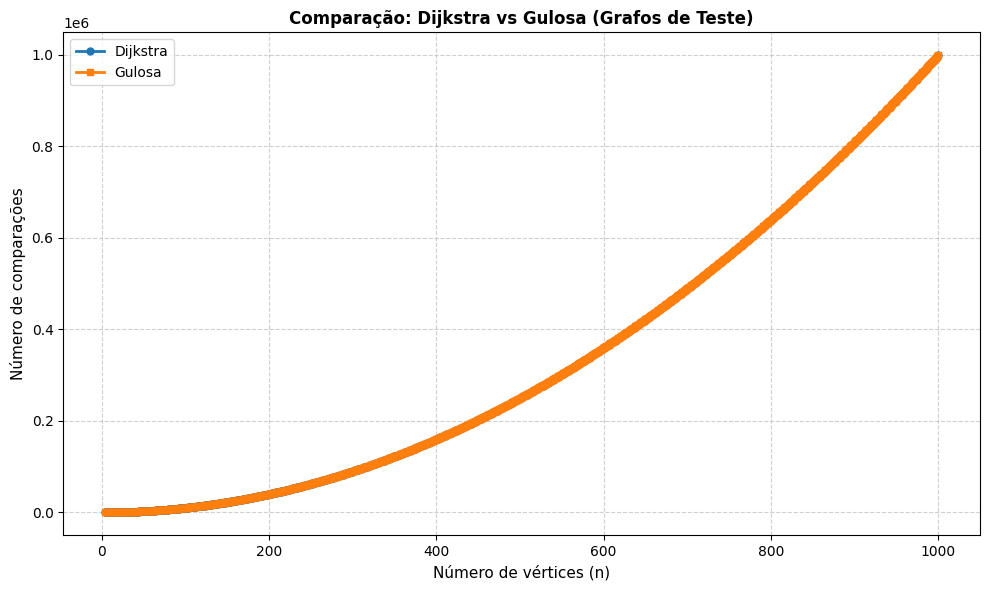

In [26]:
# Gráfico comparativo - grafos de teste
plt.figure(figsize=(10, 6))
plt.plot(ns_teste, comparacoes_teste, marker='o', label='Dijkstra', linewidth=2, markersize=5)
plt.plot(ns_teste, comparacoes_gulosa_teste, marker='s', label='Gulosa', linewidth=2, markersize=5)
plt.xlabel('Número de vértices (n)', fontsize=11)
plt.ylabel('Número de comparações', fontsize=11)
plt.title('Comparação: Dijkstra vs Gulosa (Grafos de Teste)', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

os.makedirs('resultados/comparacao', exist_ok=True)
plt.savefig('resultados/comparacao/teste_dijkstra_vs_gulosa.png', dpi=150)
print('✓ Gráfico salvo: resultados/comparacao/teste_dijkstra_vs_gulosa.png')
plt.show()

## Comparação em Instâncias Grandes

In [27]:
# Comparação numérica das instâncias grandes
print('\n' + '='*70)
print('📊 COMPARAÇÃO FINAL - INSTÂNCIAS GRANDES')
print('='*70)

if 'comp_dijkstra_10k' in locals() and 'comp_gulosa_10k' in locals():
    if comp_dijkstra_10k is not None and comp_gulosa_10k is not None:
        print('\n🔹 INSTÂNCIA 10.000 VÉRTICES')
        print('-' * 70)
        print(f'  Dijkstra:          {comp_dijkstra_10k:>15,} comparações')
        print(f'  Heurística Gulosa: {comp_gulosa_10k:>15,} comparações')
        reducao = (1 - comp_gulosa_10k / comp_dijkstra_10k) * 100
        print(f'  Redução:           {reducao:>15.2f}%')
        
        if comp_gulosa_10k < comp_dijkstra_10k:
            print(f'  ✓ Gulosa: {comp_dijkstra_10k - comp_gulosa_10k:,} comparações a MENOS')
        else:
            print(f'  ⚠ Gulosa: {comp_gulosa_10k - comp_dijkstra_10k:,} comparações a MAIS')

# Descomente após executar 1M:

if 'comp_dijkstra_1m' in locals() and 'comp_gulosa_1m' in locals():
    if comp_dijkstra_1m is not None and comp_gulosa_1m is not None:
        print('\n🔹 INSTÂNCIA 1.000.000 VÉRTICES')
        print('-' * 70)
        print(f'  Dijkstra:          {comp_dijkstra_1m:>15,} comparações')
        print(f'  Heurística Gulosa: {comp_gulosa_1m:>15,} comparações')
        reducao_1m = (1 - comp_gulosa_1m / comp_dijkstra_1m) * 100
        print(f'  Redução:           {reducao_1m:>15.2f}%')
        
        if comp_gulosa_1m < comp_dijkstra_1m:
            print(f'  ✓ Gulosa: {comp_dijkstra_1m - comp_gulosa_1m:,} comparações a MENOS')
        else:
            print(f'  ⚠ Gulosa: {comp_gulosa_1m - comp_dijkstra_1m:,} comparações a MAIS')


print('\n' + '='*70)


📊 COMPARAÇÃO FINAL - INSTÂNCIAS GRANDES

🔹 INSTÂNCIA 10.000 VÉRTICES
----------------------------------------------------------------------
  Dijkstra:                  123,462 comparações
  Heurística Gulosa:             424 comparações
  Redução:                     99.66%
  ✓ Gulosa: 123,038 comparações a MENOS

🔹 INSTÂNCIA 1.000.000 VÉRTICES
----------------------------------------------------------------------
  Dijkstra:               15,172,126 comparações
  Heurística Gulosa:           1,847 comparações
  Redução:                     99.99%
  ✓ Gulosa: 15,170,279 comparações a MENOS



✓ Gráfico salvo: resultados/comparacao/instancias_grandes.png


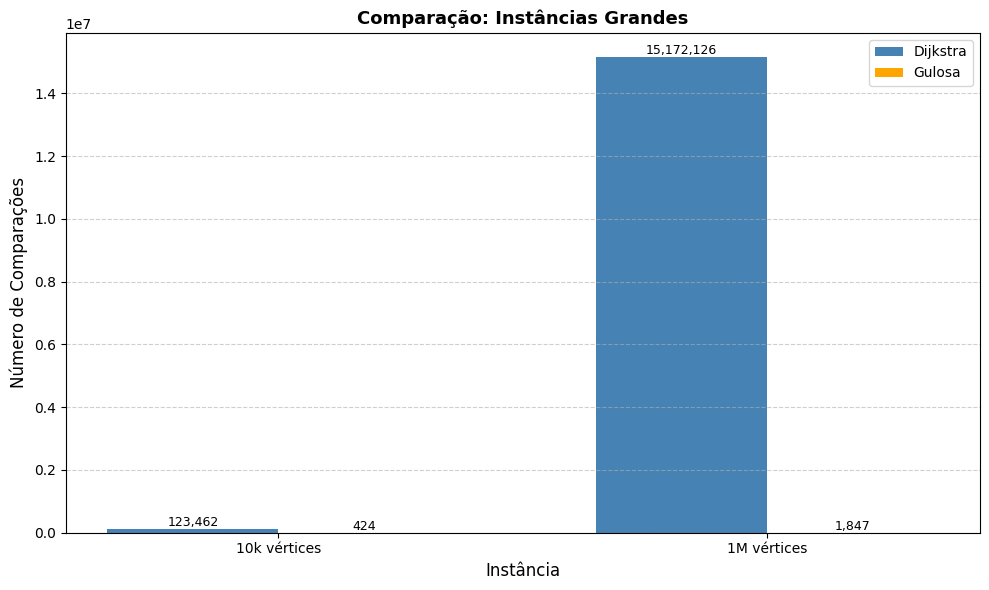

In [28]:
# Gráfico de barras - instâncias grandes
if 'comp_dijkstra_10k' in locals() and 'comp_gulosa_10k' in locals():
    if comp_dijkstra_10k is not None and comp_gulosa_10k is not None:
        instancias = ['10k vértices']
        dijkstra_vals = [comp_dijkstra_10k]
        gulosa_vals = [comp_gulosa_10k]
        
        # Adicionar 1M se executado
        if 'comp_dijkstra_1m' in locals() and comp_dijkstra_1m is not None:
            instancias.append('1M vértices')
            dijkstra_vals.append(comp_dijkstra_1m)
            gulosa_vals.append(comp_gulosa_1m)
        
        x = np.arange(len(instancias))
        width = 0.35
        
        fig, ax = plt.subplots(figsize=(10, 6))
        bars1 = ax.bar(x - width/2, dijkstra_vals, width, label='Dijkstra', color='steelblue')
        bars2 = ax.bar(x + width/2, gulosa_vals, width, label='Gulosa', color='orange')
        
        ax.set_xlabel('Instância', fontsize=12)
        ax.set_ylabel('Número de Comparações', fontsize=12)
        ax.set_title('Comparação: Instâncias Grandes', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(instancias)
        ax.legend()
        ax.grid(True, axis='y', linestyle='--', alpha=0.6)
        
        # Valores nas barras
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{int(height):,}', ha='center', va='bottom', fontsize=9)
        
        plt.tight_layout()
        plt.savefig('resultados/comparacao/instancias_grandes.png', dpi=150)
        print('✓ Gráfico salvo: resultados/comparacao/instancias_grandes.png')
        plt.show()

In [29]:
# Salvar relatório completo
with open('resultados/comparacao/relatorio_completo.txt', 'w', encoding='utf-8') as f:
    f.write('RELATÓRIO COMPLETO: DIJKSTRA vs HEURÍSTICA GULOSA\n')
    f.write('='*70 + '\n\n')
    
    f.write('GRAFOS DE TESTE\n')
    f.write('-'*70 + '\n')
    f.write(f'Tamanhos testados: n={N_MIN} até n={N_MAX}\n')
    f.write(f'Dijkstra - Comparações: min={min(comparacoes_teste):,}, max={max(comparacoes_teste):,}\n')
    f.write(f'Gulosa - Comparações: min={min(comparacoes_gulosa_teste):,}, max={max(comparacoes_gulosa_teste):,}\n\n')
    
    if 'comp_dijkstra_10k' in locals() and comp_dijkstra_10k is not None:
        f.write('INSTÂNCIA 10.000 VÉRTICES\n')
        f.write('-'*70 + '\n')
        f.write(f'Dijkstra: {comp_dijkstra_10k:,} comparações\n')
        if 'comp_gulosa_10k' in locals() and comp_gulosa_10k is not None:
            f.write(f'Gulosa: {comp_gulosa_10k:,} comparações\n')
            f.write(f'Redução: {(1 - comp_gulosa_10k/comp_dijkstra_10k)*100:.2f}%\n\n')

print('✓ Relatório completo salvo: resultados/comparacao/relatorio_completo.txt')

✓ Relatório completo salvo: resultados/comparacao/relatorio_completo.txt
